In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl
mpl.rcParams['image.cmap'] = 'bwr'

from src import *

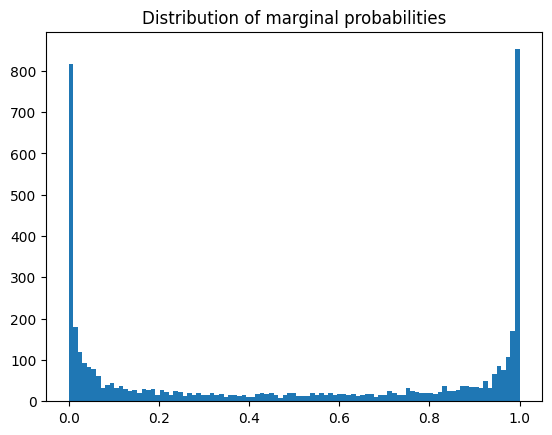

In [3]:
# Dice loss function on binary numbers
dice_loss = lambda y, y_hat: 1 - 2 * bin(y & y_hat).count("1") / (bin(y).count("1") + bin(y_hat).count("1") + 1e-3)

# number of pixels
w = 3
n = w * w

# marginal probabilities
Pyi = np.array([sp.special.expit(np.random.RandomState(x).normal(0,5,n)) for x in range(2**n)])

# image-level output probability derived from pixel-level probabilities
def get_Py_x(y, x):
    y_probs = np.where([yi == '1' for yi in np.binary_repr(y, width=n)], Pyi[x], 1 - Pyi[x])
    return np.prod(y_probs)
Py_x = np.vectorize(get_Py_x)(*np.meshgrid(np.arange(2**n), np.arange(2**n)))

plt.hist(Pyi.flatten(), bins=np.linspace(0,1,100))
plt.title("Distribution of marginal probabilities")
plt.show()

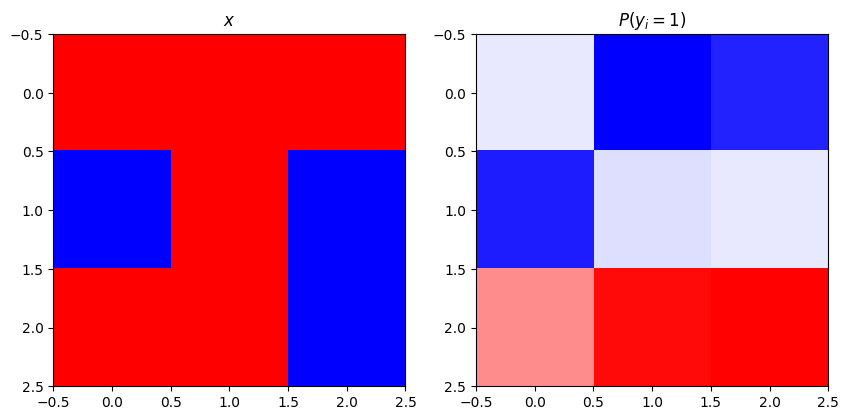

In [4]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(int2img(x, n=n))
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

fig.show()

Completely random marginal probabilities.

## Ideal Model

Model is based on the actual marginals.

In [5]:
def SDC(y_hat, hatPyi):
    # y_hat_ = int2img(y_hat, n=n).flatten()
    # return 2 * (y_hat_ * hatPyi).sum() / (np.sum(y_hat_) + hatPyi.sum())
    tp = np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi, 0).sum()
    return 2 * tp / (bin(y_hat).count("1") + hatPyi.sum())

def aMSP(y_hat, hatPyi):
    return np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi, 1-hatPyi).mean()

In [6]:
h = lambda x: ((2**np.arange(n)) * (Pyi[x] >= 0.5)).sum()

Y_pred = np.vectorize(h)(np.arange(2**n))

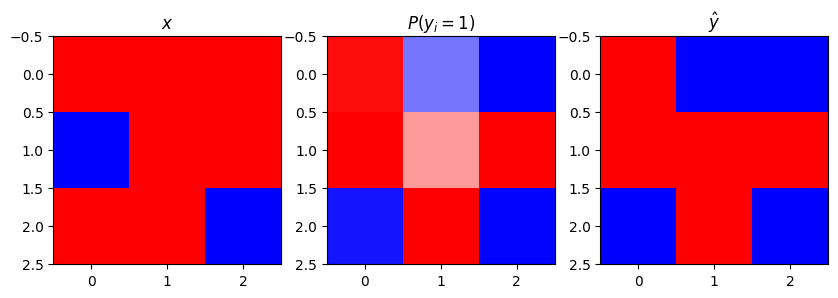

In [7]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(int2img(x, n=n))
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

axs[2].imshow(int2img(Y_pred[x], n=n), vmin=0, vmax=1)
axs[2].set_title("$\hat{y}$")

fig.show()

### True RC curve

Using the actual conditional risk, computed from the entire population ($\mathcal{X}$).

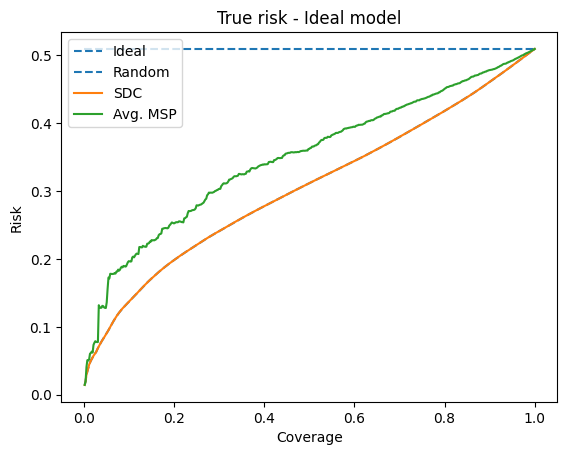

In [8]:
r = get_true_conditional_risk(dice_loss, Py_x, h, n=n)

R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

ideal_risks, coverages = rc_curve_(R_x, -R_x)

plt.plot(coverages, ideal_risks, linestyle='--', label="Ideal")
plt.hlines(ideal_risks[-1], 0, 1, linestyles='--', label="Random")

sdc_risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_pred[x], Pyi[x]))(np.arange(2**n)))

plt.plot(coverages, sdc_risks, label="SDC")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_pred[x], Pyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

plt.legend()
plt.title("True risk - Ideal model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.show()

### Sampled target

Instead of computing the actual conditional risk, we generate targets based on the marginal probabilities, and use that to estimate the risk.

In [9]:
Y = np.vectorize(lambda x: np.sum((2**np.arange(n)) * (np.random.RandomState(x+1).rand(n) < Pyi[x])))(np.arange(2**n))

print("Mean dice score = ", 1 - np.vectorize(dice_loss)(Y_pred, Y).mean())

Mean dice score =  0.8746550827485478


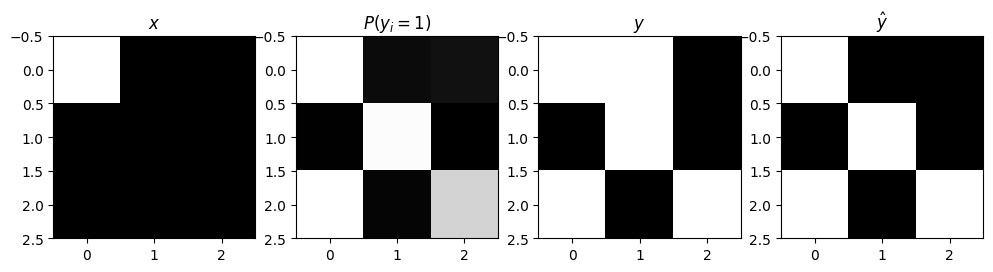

In [10]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 4, figsize=(12, 5))

axs[0].imshow(int2img(x, n=n), cmap='gray')
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), cmap='gray', vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

axs[2].imshow(int2img(Y[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("$y$")

axs[3].imshow(int2img(Y_pred[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[3].set_title("$\hat{y}$")

fig.show()

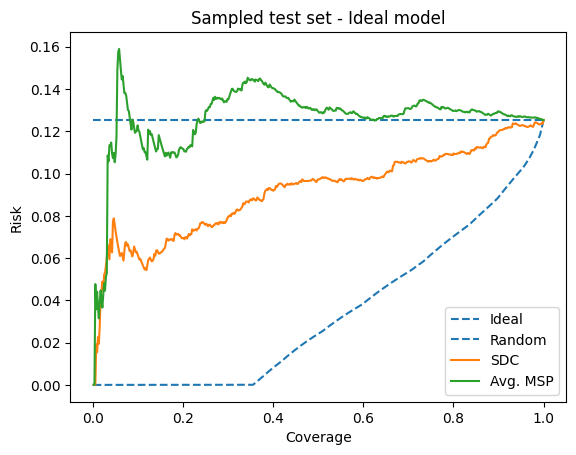

In [11]:
errors = np.vectorize(dice_loss)(Y_pred, Y)
risks, coverages = rc_curve_(errors, -errors)

plt.plot(coverages, risks, linestyle='--', label="Ideal")
plt.hlines(risks[-1], 0, 1, linestyles='--', label="Random")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_pred[x], Pyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="SDC")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: aMSP(Y_pred[x], Pyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

plt.legend()
plt.title("Sampled test set - Ideal model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.show()

In [12]:
def b_U(k, mu, lam, tol=1e-12):
    """
    Parameters:
        max_terms (int): Maximum number of terms to sum in the series.
        tol (float): Convergence tolerance.
    """
    numerator_constant = np.float128(k + k * mu + lam)  # Precompute numerator constant
    denominator_base = np.float128(k + k * mu)  # Precompute denominator base
    e_neg_lam = np.exp(-lam, dtype=np.float128)  # Precompute e^(-lambda)

    b_u_value = 0.0

    i = 0
    lam_to_the_i = lam ** 0
    cum_prob = 0
    poisson_term = e_neg_lam  # Poisson probability
    while True:
        fraction = numerator_constant / (denominator_base + i)  # Fraction term
        term = poisson_term * fraction  # Current term

        b_u_value += term
        cum_prob += poisson_term

        # Check for convergence
        # if term < tol:
        #     break
        if (cum_prob > 0.99) and (term < tol):
            break

        i += 1
        lam_to_the_i = lam_to_the_i * lam
        poisson_term = poisson_term * (lam / i)

    return b_u_value

def b_L(k, mu, lam):
    return (k + k*mu + lam) / (k + 1 + (k - 1)*mu + lam)

x = np.random.choice(2**n)

k = Y_pred[x].bit_count()
mu = np.where([yi_hat == '1' for yi_hat in np.binary_repr(Y_pred[x], width=n)], Pyi[x], 0).sum() / k
s0 = np.where([yi_hat == '0' for yi_hat in np.binary_repr(Y_pred[x], width=n)], Pyi[x], 0).sum()

b_L(k, mu, s0), b_U(k, mu, 1e3)
# b_U(100, 0.0, 1e4, tol=1e-6)

(np.float64(0.9883450019448726),
 np.longdouble('1.0009766589601946417990634859079735'))

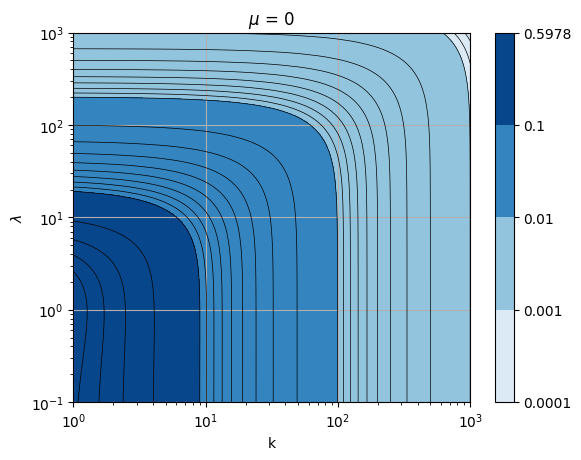

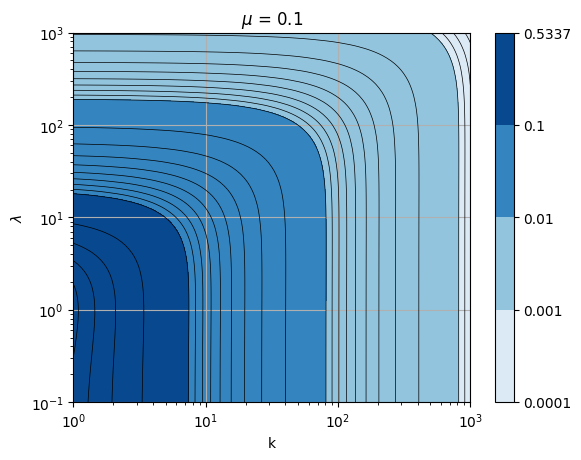

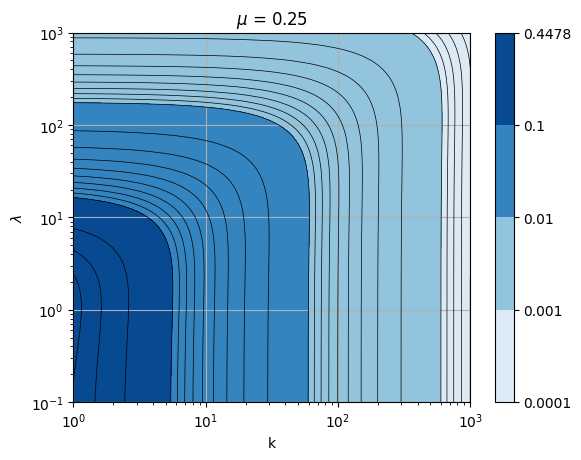

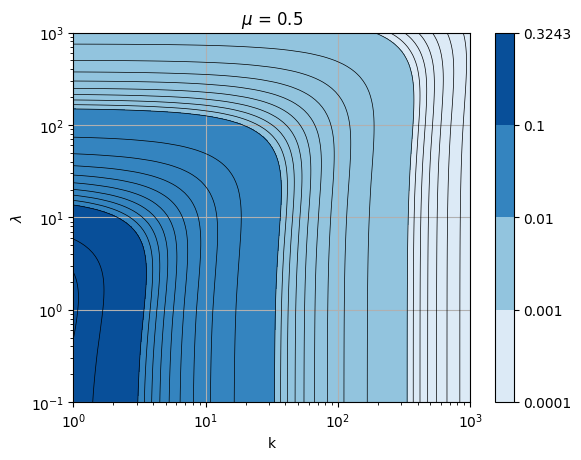

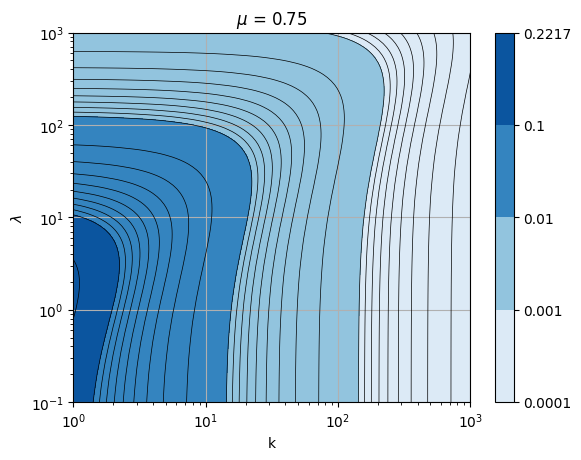

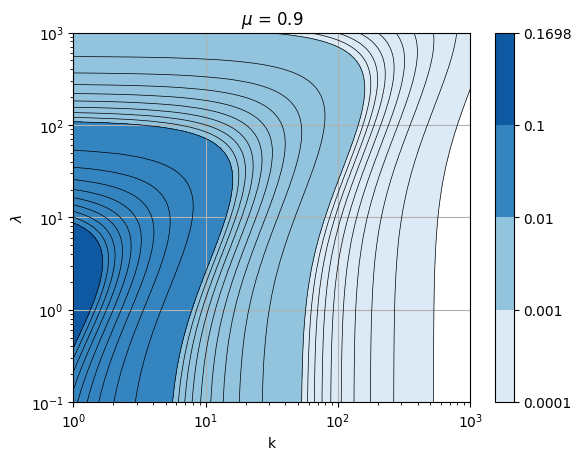

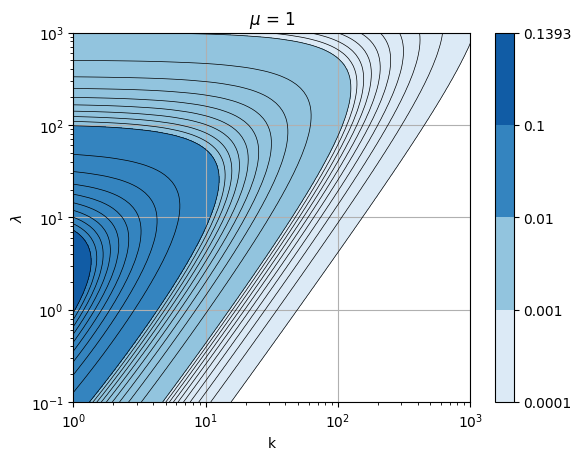

In [13]:
k = np.unique(np.geomspace(1, 1000, 101)) #.astype(int))
s0 = np.geomspace(0.1, 1000, 100)
mus = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]

k_, s0_ = np.meshgrid(k, s0)

es = {}
for mu in mus:
    e = np.vectorize(lambda k, s0: b_U(k, mu, s0) - b_L(k, mu, s0))(k_, s0_)
    es[mu] = e

path = r'.'

for i, mu in enumerate(mus):
    e = es[mu]
    levels = [np.round(e.max(), 4), 0.1, 0.01, 0.001, 0.0001][::-1]
    plt.contourf(k_, s0_, np.log10(e), levels=np.log10(levels), vmax = np.log10(0.5), vmin=np.log10(1e-4), cmap='Blues')
    cbar = plt.colorbar()
    cbar.set_ticklabels(levels)
    plt.contour(k_, s0_, e, levels=np.hstack([np.arange(1, 10)*a for a in [0.1, 0.01, 0.001, 0.0001][::-1]]), linewidths=0.5, colors='k')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.1, 1000)
    plt.xlabel('k')
    plt.ylabel('$\lambda$')
    plt.title(f'$\mu$ = {mu}')
    plt.grid('on')
    fig_id = f'{mu:.2f}'.replace('.','')
    # plt.savefig(f'{path}/contour{fig_id}.pdf')
    plt.show()

/tmp/ipykernel_56011/807791705.py:2: RuntimeWarning: invalid value encountered in scalar divide
  Mu = np.array([np.where([yi_pred == '1' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() / K[x] for x, y_pred in enumerate(Y_pred)])


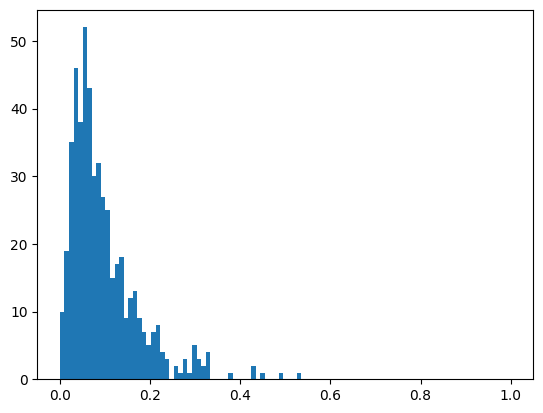

In [14]:
K = np.array([y_pred.bit_count() for y_pred in Y_pred])
Mu = np.array([np.where([yi_pred == '1' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() / K[x] for x, y_pred in enumerate(Y_pred)])
# Mu[np.isnan(Mu)] = 0
Lambda = np.array([np.where([yi_pred == '0' for yi_pred in np.binary_repr(y_pred, width=n)], Pyi[x], 0).sum() for x, y_pred in enumerate(Y_pred)])

bounds = np.vectorize(lambda k, mu, lam: b_U(k, mu, lam) - b_L(k, mu, lam))(K[K > 0], Mu[K > 0], Lambda[K > 0])

plt.hist(bounds, bins=np.linspace(0,1,100))
plt.show()

In [23]:
B_U = np.vectorize(b_U)(K[K > 0], Mu[K > 0], Lambda[K > 0])
np.any(B_U < 1.0)

np.False_

## Random Model

In [15]:
h_dummy = lambda x: np.random.RandomState(x+2).randint(0, 2**n)

print("Mean dice score = ", 1 - np.vectorize(lambda x: dice_loss(h_dummy(x), Y[x]))(Y).mean())

Mean dice score =  0.4763499462352405


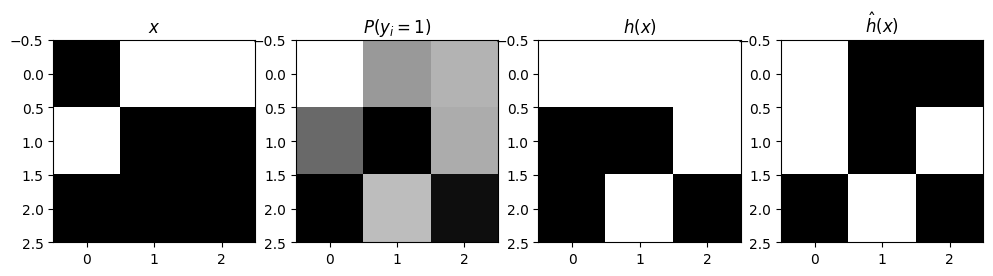

In [16]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 4, figsize=(12, 5))

axs[0].imshow(int2img(x, n=n), cmap='gray')
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), cmap='gray', vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

axs[2].imshow(int2img(h(x), n=n), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("$h(x)$")

axs[3].imshow(int2img(h_dummy(x), n=n), cmap='gray', vmin=0, vmax=1)
axs[3].set_title("$\hat{h}(x)$")

fig.show()

## Non-ideal Model

Model is based on the actual marginals.

In [17]:
# pixel-level probability is predicted with a gaussian noise at the logits
def hatpyi(x):
    z = sp.special.logit(Pyi[x])
    zhat = np.random.RandomState(x+33).normal(z, scale=2.0)
    return sp.special.expit(zhat)

hatPyi = np.vstack([hatpyi(x) for x in np.arange(2**n)])

h_hat = lambda x: ((2**np.arange(n)) * (hatPyi[x] >= 0.5)).sum()

Y_hat = np.vectorize(h_hat)(np.arange(2**n))

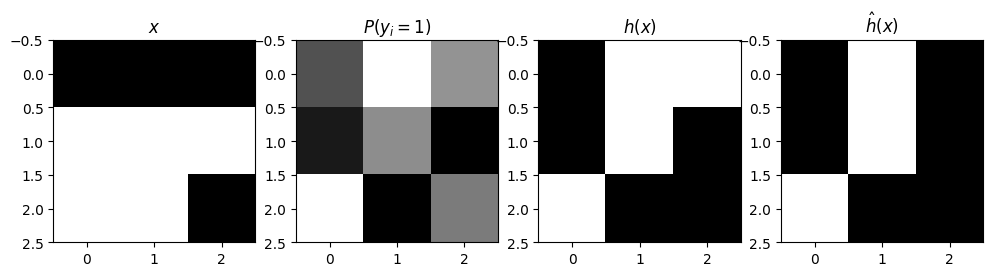

In [18]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 4, figsize=(12, 5))

axs[0].imshow(int2img(x, n=n), cmap='gray')
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), cmap='gray', vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

axs[2].imshow(int2img(Y_pred[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("$h(x)$")

axs[3].imshow(int2img(Y_hat[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[3].set_title("$\hat{h}(x)$")

fig.show()

### True RC curve

Using the actual conditional risk, computed from the entire population ($\mathcal{X}$).

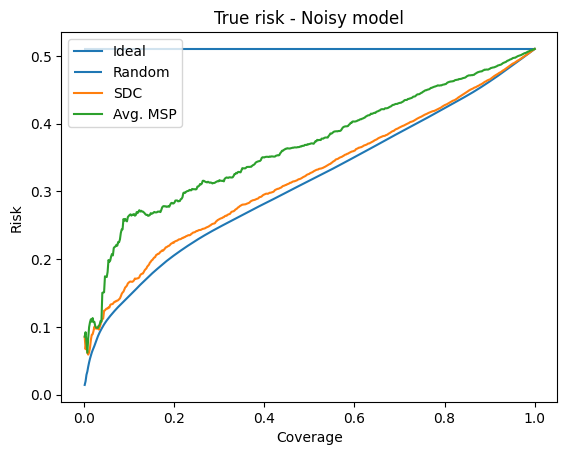

In [19]:
r = get_true_conditional_risk(dice_loss, Py_x, h_hat, n=n)

R_x = np.vectorize(r)(np.arange(2**n))  # conditional risk

risks, coverages = rc_curve_(R_x, -R_x)

plt.plot(coverages, risks, label="Ideal")
plt.hlines(risks[-1], 0, 1, label="Random")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="SDC")

risks, coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

plt.legend()
plt.title("True risk - Noisy model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.show()

### Sampled target

Instead of computing the actual conditional risk, we generate targets based on the marginal probabilities, and use that to estimate the risk.

In [20]:
print("Mean dice score = ", 1 - np.vectorize(dice_loss)(Y,Y_hat).mean())

Mean dice score =  0.8162994917708277


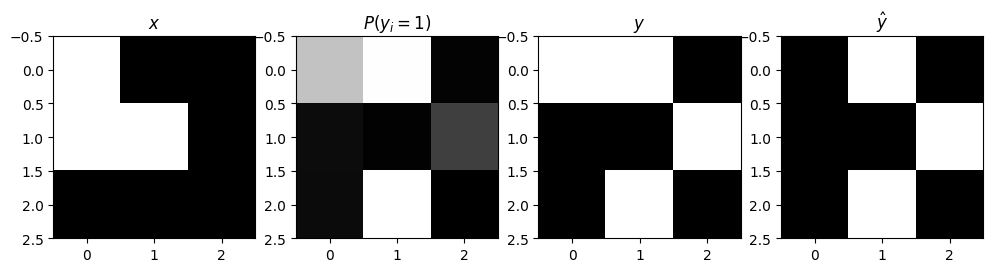

In [21]:
x = np.random.choice(2**n)

fig, axs = plt.subplots(1, 4, figsize=(12, 5))

axs[0].imshow(int2img(x, n=n), cmap='gray')
axs[0].set_title("$x$")

axs[1].imshow(Pyi[x].reshape(w, w), cmap='gray', vmin=0, vmax=1)
axs[1].set_title("$P(y_i=1)$")

axs[2].imshow(int2img(Y[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("$y$")

axs[3].imshow(int2img(Y_hat[x], n=n), cmap='gray', vmin=0, vmax=1)
axs[3].set_title("$\hat{y}$")

fig.show()

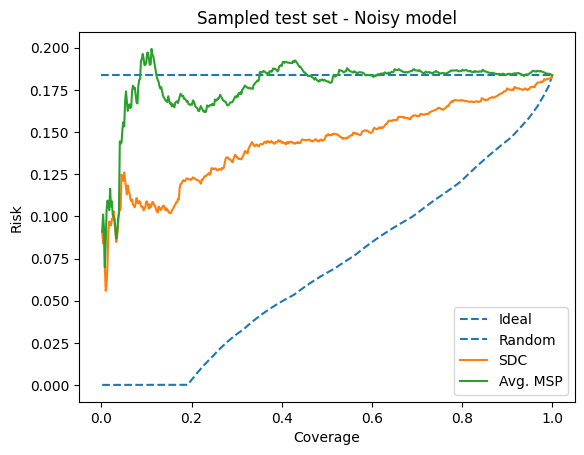

In [22]:
errors = np.vectorize(dice_loss)(Y, Y_hat)
risks, coverages = rc_curve_(errors, -errors)

plt.plot(coverages, risks, linestyle='--', label="Ideal")
plt.hlines(risks[-1], 0, 1, linestyles='--', label="Random")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="SDC")

risks, coverages = rc_curve_(errors, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(2**n)))

plt.plot(coverages, risks, label="Avg. MSP")

plt.legend()
plt.title("Sampled test set - Noisy model")
plt.xlabel("Coverage")
plt.ylabel("Risk")
plt.show()